In [1]:
from requests import Request, Session
from requests.exceptions import ConnectionError, Timeout, TooManyRedirects
import json

url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
#Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
parameters = {
  'start':'1',
  'limit':'15',
  'convert':'USD'
}
headers = {
  'Accepts': 'application/json',
  'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
}

session = Session()
session.headers.update(headers)

try:
  response = session.get(url, params=parameters)
  data = json.loads(response.text)
  #print(data)
except (ConnectionError, Timeout, TooManyRedirects) as e:
  print(e)

#NOTE:
# I had to go in and put "jupyter notebook --NotebookApp.iopub_data_rate_limit=1e10"
# Into the Anaconda Prompt to change this to allow to pull data

# If that didn't work try using the local host URL as shown in the video

In [2]:
type(data)

dict

In [3]:
import pandas as pd


#This allows you to see all the columns, not just like 15
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [4]:
df = pd.json_normalize(data['data'])
df['timestamp'] = pd.to_datetime('now')
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.002602e+07,2.002602e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12626,1,2026-05-07T16:56:00.000Z,None,NaN,NaN,NaN,1.599345e+12,"[mineable, pow, sha-256, store-of-value, state...",79863.339750,3.637804e+10,3.633753e+10,4.051200e+07,-16.9083,-0.103159,-2.200145,4.747325,17.113818,19.364192,14.228470,1.599345e+12,60.1029,1.677130e+12,None,2026-05-07T16:56:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134
1,1027,Ethereum,ETH,ethereum,True,1.206871e+08,1.206871e+08,NaN,2015-08-07T00:00:00.000Z,11926,2,2026-05-07T16:55:00.000Z,None,NaN,NaN,NaN,2.768602e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",2294.032696,2.132783e+10,2.119886e+10,1.289686e+08,-2.7717,-0.113047,-2.718439,1.629001,10.083931,18.415624,12.454229,2.768602e+11,10.4043,2.768602e+11,None,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134
2,825,Tether USDt,USDT,tether,True,1.896511e+11,1.942035e+11,NaN,2015-02-25T00:00:00.000Z,180760,3,2026-05-07T16:55:00.000Z,None,NaN,NaN,NaN,1.941543e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.999746,2.387879e+11,2.369181e+11,1.869814e+09,62.2754,0.003828,0.007147,0.010296,0.000010,-0.017484,0.006175,1.896030e+11,7.1252,1.941543e+11,None,2026-05-07T16:55:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-07 18:58:29.748134
3,1839,BNB,BNB,bnb,False,1.347858e+08,1.347858e+08,1.347858e+08,2017-07-25T00:00:00.000Z,3218,4,2026-05-07T16:55:00.000Z,None,NaN,NaN,NaN,8.658419e+10,"[marketplace, centralized-exchange, payments, ...",642.383682,1.659978e+09,1.643943e+09,1.603507e+07,-34.6535,-0.115284,-1.047532,4.244207,6.802877,4.888176,-2.955644,8.658419e+10,3.2538,8.658419e+10,None,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134
4,52,XRP,XRP,xrp,False,6.179623e+10,9.998567e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1830,5,2026-05-07T16:55:00.000Z,None,NaN,NaN,NaN,1.389770e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.389970,2.066461e+09,2.065842e+09,6.193411e+05,-31.5690,-0.218018,-2.884595,1.730341,6.848411,3.713374,-7.434913,8.589488e+10,3.2279,1.389970e+11,None,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134
5,3408,USDC,USDC,usd-coin,False,7.831567e+10,7.831567e+10,NaN,2018-10-08T00:00:00.000Z,39309,6,2026-05-07T16:55:00.000Z,None,NaN,6.090122e+10,6.088328e+10,7.829260e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999705,4.819213e+10,4.594584e+10,2.246289e+09,-21.9472,0.007517,-0.016560,-0.006529,-0.008500,-0.024063,-0.040620,7.829260e+10,2.9422,7.829260e+10,None,2026-05-07T16:55:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-05-07 18:58:29.748134
6,5426,Solana,SOL,solana,True,5.772021e+08,6.259644e+08,NaN,2020-04-10T00:00:00.000Z,1126,7,2026-05-07T16:55:00.000Z,None,NaN,5.252369e+08,4.650590e+10,5.542458e+10,"[pos, platform, solana-ecosystem, cms-holdings...",88.542710,4.782706e+09,4.782680e+09,2.520717e+04,-19.1592,0.098982,-0.899067,6.540090,12.228113,8.636385,1.723027,5.110704e+10,1.9206,5.542458e+10,None,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134
7,1958,TRON,TRX,tron,True,9.479313e+10,9.479313e+10,NaN,2017-09-13T00:00:00.000Z,1338,8,2026-05-07T16:56:00.000Z,None,NaN,9.4

In [18]:
def api_runner():
    global df
    url = 'https://pro-api.coinmarketcap.com/v1/cryptocurrency/listings/latest' 
    #Original Sandbox Environment: 'https://sandbox-api.coinmarketcap.com/v1/cryptocurrency/listings/latest'
    parameters = {
      'start':'1',
      'limit':'15',
      'convert':'USD'
    }
    headers = {
      'Accepts': 'application/json',
      'X-CMC_PRO_API_KEY': '0ad53085-1cb2-4eb8-ad9e-3ffbd7e56509',
    }

    session = Session()
    session.headers.update(headers)

    try:
      response = session.get(url, params=parameters)
      data = json.loads(response.text)
      #print(data)
    except (ConnectionError, Timeout, TooManyRedirects) as e:
      print(e)
        
    df2 = pd.json_normalize(data['data'])
    df2['Timestamp'] = pd.to_datetime('now')
    df = pd.concat([df, df2], ignore_index=True)

    if not os.path.isfile('/Users/jakubskoneczny/Api.csv'):
        df.to_csv('/Users/jakubskoneczny/Api.csv', header='column_names')
    else:
        df.to_csv('/Users/jakubskoneczny/Api.csv', mode='a', header=False)

In [19]:
import os 
from time import time
from time import sleep

for i in range(333):
    api_runner()
    print('API Runner completed')
    sleep(60) #sleep for 1 minute
exit()

API Runner completed
API Runner completed
API Runner completed


KeyboardInterrupt: 

In [20]:
df72 = pd.read_csv('/Users/jakubskoneczny/Api.csv')
df72

,Unnamed: 0,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp,Timestamp
0,0,1,Bitcoin,BTC,bitcoin,False,2.002602e+07,2.002602e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12626,1,2026-05-07T16:56:00.000Z,NaN,NaN,NaN,NaN,1.599345e+12,"['mineable', 'pow', 'sha-256', 'store-of-value...",79863.339750,3.637804e+10,3.633753e+10,4.051200e+07,-16.9083,-0.103159,-2.200145,4.747325,17.113818,19.364192,14.228470,1.599345e+12,60.1029,1.677130e+12,NaN,2026-05-07T16:56:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134,NaN
1,1,1027,Ethereum,ETH,ethereum,True,1.206871e+08,1.206871e+08,NaN,2015-08-07T00:00:00.000Z,11926,2,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,2.768602e+11,"['pos', 'smart-contracts', 'ethereum-ecosystem...",2294.032696,2.132783e+10,2.119886e+10,1.289686e+08,-2.7717,-0.113047,-2.718439,1.629001,10.083931,18.415624,12.454229,2.768602e+11,10.4043,2.768602e+11,NaN,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134,NaN
2,2,825,Tether USDt,USDT,tether,True,1.896511e+11,1.942035e+11,NaN,2015-02-25T00:00:00.000Z,180760,3,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,1.941543e+11,"['stablecoin', 'asset-backed-stablecoin', 'usd...",0.999746,2.387879e+11,2.369181e+11,1.869814e+09,62.2754,0.003828,0.007147,0.010296,0.000010,-0.017484,0.006175,1.896030e+11,7.1252,1.941543e+11,NaN,2026-05-07T16:55:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-07 18:58:29.748134,NaN
3,3,1839,BNB,BNB,bnb,False,1.347858e+08,1.347858e+08,1.347858e+08,2017-07-25T00:00:00.000Z,3218,4,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,8.658419e+10,"['marketplace', 'centralized-exchange', 'payme...",642.383682,1.659978e+09,1.643943e+09,1.603507e+07,-34.6535,-0.115284,-1.047532,4.244207,6.802877,4.888176,-2.955644,8.658419e+10,3.2538,8.658419e+10,NaN,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134,NaN
4,4,52,XRP,XRP,xrp,False,6.179623e+10,9.998567e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1830,5,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,1.389770e+11,"['medium-of-exchange', 'enterprise-solutions',...",1.389970,2.066461e+09,2.065842e+09,6.193411e+05,-31.5690,-0.218018,-2.884595,1.730341,6.848411,3.713374,-7.434913,8.589488e+10,3.2279,1.389970e+11,NaN,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134,NaN
5,5,3408,USDC,USDC,usd-coin,False,7.831567e+10,7.831567e+10,NaN,2018-10-08T00:00:00.000Z,39309,6,2026-05-07T16:55:00.000Z,NaN,NaN,6.090122e+10,6.088328e+10,7.829260e+10,"['medium-of-exchange', 'stablecoin', 'asset-ba...",0.999705,4.819213e+10,4.594584e+10,2.246289e+09,-21.9472,0.007517,-0.016560,-0.006529,-0.008500,-0.024063,-0.040620,7.829260e+10,2.9422,7.829260e+10,NaN,2026-05-07T16:55:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-05-07 18:58:29.748134,NaN
6,6,5426,Solana,SOL,solana,True,5.772021e+08,6.259644e+08,NaN,2020-04-10T00:00:00.000Z,1126,7,2026-05-07T16:55:00.000Z,NaN,NaN,5.252369e+08,4.650590e+10,5.542458e+10,"['pos', 'platform', 'solana-ecosystem', 'cms-h...",88.542710,4.782706e+09,4.782680e+09,2.520717e+04,-19.1592,0.098982,-0.899067,6.540090,12.228113,8.636385,1.723027,5.110704e+10,1.9206,5.542458e+10,NaN,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134,NaN
7,7,1958,TRON,TRX,tron,True,9.479313e+10,9.479313e+10,NaN,2017-09-13T00:00:0

# Assistant
This error occurs because the `append()` method for pandas DataFrames was deprecated and removed in newer versions of pandas. The error is happening inside the `api_runner()` function, where there's likely code trying to use `df.append()` on a DataFrame.

The error message indicates that somewhere in your `api_runner()` function, you're trying to use the `.append()` method on a DataFrame, which is no longer available in recent pandas versions.

Would you like me to provide the corrected code?

In [17]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp,Timestamp
0,1,Bitcoin,BTC,bitcoin,False,2.002602e+07,2.002602e+07,2.100000e+07,2010-07-13T00:00:00.000Z,12626,1,2026-05-07T16:56:00.000Z,None,NaN,NaN,NaN,1.599345e+12,"[mineable, pow, sha-256, store-of-value, state...",79863.339750,3.637804e+10,3.633753e+10,4.051200e+07,-16.9083,-0.103159,-2.200145,4.747325,17.113818,19.364192,14.228470,1.599345e+12,60.1029,1.677130e+12,None,2026-05-07T16:56:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134,NaT
1,1027,Ethereum,ETH,ethereum,True,1.206871e+08,1.206871e+08,NaN,2015-08-07T00:00:00.000Z,11926,2,2026-05-07T16:55:00.000Z,None,NaN,NaN,NaN,2.768602e+11,"[pos, smart-contracts, ethereum-ecosystem, coi...",2294.032696,2.132783e+10,2.119886e+10,1.289686e+08,-2.7717,-0.113047,-2.718439,1.629001,10.083931,18.415624,12.454229,2.768602e+11,10.4043,2.768602e+11,None,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134,NaT
2,825,Tether USDt,USDT,tether,True,1.896511e+11,1.942035e+11,NaN,2015-02-25T00:00:00.000Z,180760,3,2026-05-07T16:55:00.000Z,None,NaN,NaN,NaN,1.941543e+11,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.999746,2.387879e+11,2.369181e+11,1.869814e+09,62.2754,0.003828,0.007147,0.010296,0.000010,-0.017484,0.006175,1.896030e+11,7.1252,1.941543e+11,None,2026-05-07T16:55:00.000Z,1027.0,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-07 18:58:29.748134,NaT
3,1839,BNB,BNB,bnb,False,1.347858e+08,1.347858e+08,1.347858e+08,2017-07-25T00:00:00.000Z,3218,4,2026-05-07T16:55:00.000Z,None,NaN,NaN,NaN,8.658419e+10,"[marketplace, centralized-exchange, payments, ...",642.383682,1.659978e+09,1.643943e+09,1.603507e+07,-34.6535,-0.115284,-1.047532,4.244207,6.802877,4.888176,-2.955644,8.658419e+10,3.2538,8.658419e+10,None,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134,NaT
4,52,XRP,XRP,xrp,False,6.179623e+10,9.998567e+10,1.000000e+11,2013-08-04T00:00:00.000Z,1830,5,2026-05-07T16:55:00.000Z,None,NaN,NaN,NaN,1.389770e+11,"[medium-of-exchange, enterprise-solutions, xrp...",1.389970,2.066461e+09,2.065842e+09,6.193411e+05,-31.5690,-0.218018,-2.884595,1.730341,6.848411,3.713374,-7.434913,8.589488e+10,3.2279,1.389970e+11,None,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134,NaT
5,3408,USDC,USDC,usd-coin,False,7.831567e+10,7.831567e+10,NaN,2018-10-08T00:00:00.000Z,39309,6,2026-05-07T16:55:00.000Z,None,NaN,6.090122e+10,6.088328e+10,7.829260e+10,"[medium-of-exchange, stablecoin, asset-backed-...",0.999705,4.819213e+10,4.594584e+10,2.246289e+09,-21.9472,0.007517,-0.016560,-0.006529,-0.008500,-0.024063,-0.040620,7.829260e+10,2.9422,7.829260e+10,None,2026-05-07T16:55:00.000Z,1027.0,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-05-07 18:58:29.748134,NaT
6,5426,Solana,SOL,solana,True,5.772021e+08,6.259644e+08,NaN,2020-04-10T00:00:00.000Z,1126,7,2026-05-07T16:55:00.000Z,None,NaN,5.252369e+08,4.650590e+10,5.542458e+10,"[pos, platform, solana-ecosystem, cms-holdings...",88.542710,4.782706e+09,4.782680e+09,2.520717e+04,-19.1592,0.098982,-0.899067,6.540090,12.228113,8.636385,1.723027,5.110704e+10,1.9206,5.542458e+10,None,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134,NaT
7,1958,TRON,TRX,tron,True,9.479313e+10,9.479313e+10,NaN,2017-09-13T00:00:00.000Z,1338,8

In [21]:
pd.set_option('display.float_format', lambda x: '%.5f' % x)

In [22]:
df

,id,name,symbol,slug,infinite_supply,circulating_supply,total_supply,max_supply,date_added,num_market_pairs,cmc_rank,last_updated,tvl_ratio,platform,self_reported_circulating_supply,self_reported_market_cap,minted_market_cap,tags,quote.USD.price,quote.USD.volume_24h,quote.USD.cex_volume_24h,quote.USD.dex_volume_24h,quote.USD.volume_change_24h,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d,quote.USD.market_cap,quote.USD.market_cap_dominance,quote.USD.fully_diluted_market_cap,quote.USD.tvl,quote.USD.last_updated,platform.id,platform.slug,platform.name,platform.symbol,platform.token_address,timestamp,Timestamp
0,1,Bitcoin,BTC,bitcoin,False,20026021.00000,20026021.00000,21000000.00000,2010-07-13T00:00:00.000Z,12626,1,2026-05-07T16:56:00.000Z,None,NaN,NaN,NaN,1599344918966.40991,"[mineable, pow, sha-256, store-of-value, state...",79863.33975,36378044882.50698,36337532881.62048,40512000.88650,-16.90830,-0.10316,-2.20015,4.74733,17.11382,19.36419,14.22847,1599344918966.41333,60.10290,1677130134752.90991,None,2026-05-07T16:56:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134,NaT
1,1027,Ethereum,ETH,ethereum,True,120687104.06368,120687104.06368,NaN,2015-08-07T00:00:00.000Z,11926,2,2026-05-07T16:55:00.000Z,None,NaN,NaN,NaN,276860162675.59998,"[pos, smart-contracts, ethereum-ecosystem, coi...",2294.03270,21327826505.59031,21198857891.80247,128968613.78783,-2.77170,-0.11305,-2.71844,1.62900,10.08393,18.41562,12.45423,276860162675.59534,10.40430,276860162675.59998,None,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134,NaT
2,825,Tether USDt,USDT,tether,True,189651082316.74588,194203497624.11526,NaN,2015-02-25T00:00:00.000Z,180760,3,2026-05-07T16:55:00.000Z,None,NaN,NaN,NaN,194154265882.26001,"[stablecoin, asset-backed-stablecoin, usd-stab...",0.99975,238787926276.28424,236918111833.30569,1869814442.97848,62.27540,0.00383,0.00715,0.01030,0.00001,-0.01748,0.00617,189603004639.25214,7.12520,194154265882.26001,None,2026-05-07T16:55:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xdac17f958d2ee523a2206206994597c13d831ec7,2026-05-07 18:58:29.748134,NaT
3,1839,BNB,BNB,bnb,False,134785784.62000,134785784.62000,134785786.88000,2017-07-25T00:00:00.000Z,3218,4,2026-05-07T16:55:00.000Z,None,NaN,NaN,NaN,86584188572.85001,"[marketplace, centralized-exchange, payments, ...",642.38368,1659978038.01959,1643942967.08804,16035070.93155,-34.65350,-0.11528,-1.04753,4.24421,6.80288,4.88818,-2.95564,86584188572.84798,3.25380,86584190024.64000,None,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134,NaT
4,52,XRP,XRP,xrp,False,61796225236.00000,99985670046.00000,100000000000.00000,2013-08-04T00:00:00.000Z,1830,5,2026-05-07T16:55:00.000Z,None,NaN,NaN,NaN,138977046560.23001,"[medium-of-exchange, enterprise-solutions, xrp...",1.38997,2066461066.70037,2065841725.58042,619341.11995,-31.56900,-0.21802,-2.88459,1.73034,6.84841,3.71337,-7.43491,85894877415.12192,3.22790,138996964761.34000,None,2026-05-07T16:55:00.000Z,NaN,NaN,NaN,NaN,NaN,2026-05-07 18:58:29.748134,NaT
5,3408,USDC,USDC,usd-coin,False,78315670273.14403,78315670273.14403,NaN,2018-10-08T00:00:00.000Z,39309,6,2026-05-07T16:55:00.000Z,None,NaN,60901219650.23000,60883278109.85374,78292598423.87000,"[medium-of-exchange, stablecoin, asset-backed-...",0.99971,48192130174.86722,45945841031.53480,2246289143.33250,-21.94720,0.00752,-0.01656,-0.00653,-0.00850,-0.02406,-0.04062,78292598423.87123,2.94220,78292598423.87000,None,2026-05-07T16:55:00.000Z,1027.00000,ethereum,Ethereum,ETH,0xa0b86991c6218b36c1d19d4a2e9eb0ce3606eb48,2026-05-07 18:58:29.748134,NaT
6,5426,Solana,SOL,solana,True,577202142.24770,625964397.95468,NaN,2020-04-10T00:00:00.000Z,1126,7,2026-05-07T16:55:00.000Z,None,NaN,525236893.30000,46505897924.97916,55424584158.68000,"[pos, platform, solana-ecosystem, cms-holdings...",88.54271,4782705542.42843,4782680335.25837,25207.17007,-19.15920,0.09898

In [23]:
df3 = df.groupby('name', sort=False)[['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d']].mean()
df3

,quote.USD.percent_change_1h,quote.USD.percent_change_24h,quote.USD.percent_change_7d,quote.USD.percent_change_30d,quote.USD.percent_change_60d,quote.USD.percent_change_90d
name,,,,,,
Bitcoin,0.08040,-1.94789,4.84371,16.48525,19.26350,13.54724
Ethereum,-0.02162,-2.49026,1.61517,9.57243,18.39490,11.31627
Tether USDt,0.00242,0.00169,0.01585,-0.00646,-0.01727,0.01448
BNB,-0.04759,-1.08276,4.13440,6.44934,4.66627,-2.81677
XRP,-0.06716,-2.57954,1.72945,6.48359,3.48692,-6.72908
USDC,0.00201,-0.00142,-0.00593,-0.01210,-0.01871,-0.02942
Solana,-0.06022,-0.53210,6.60929,10.94952,8.46673,1.48756
TRON,0.12487,0.92535,7.09194,11.21926,20.76223,27.78587
Dogecoin,-0.17080,-4.77420,1.96293,18.11948,21.65470,7.80247


In [24]:
df4 = df3.stack()
df4

name                                      
Bitcoin       quote.USD.percent_change_1h      0.08040
              quote.USD.percent_change_24h    -1.94789
              quote.USD.percent_change_7d      4.84371
              quote.USD.percent_change_30d    16.48525
              quote.USD.percent_change_60d    19.26350
              quote.USD.percent_change_90d    13.54724
Ethereum      quote.USD.percent_change_1h     -0.02162
              quote.USD.percent_change_24h    -2.49026
              quote.USD.percent_change_7d      1.61517
              quote.USD.percent_change_30d     9.57243
              quote.USD.percent_change_60d    18.39490
              quote.USD.percent_change_90d    11.31627
Tether USDt   quote.USD.percent_change_1h      0.00242
              quote.USD.percent_change_24h     0.00169
              quote.USD.percent_change_7d      0.01585
              quote.USD.percent_change_30d    -0.00646
              quote.USD.percent_change_60d    -0.01727
              quote.US

In [25]:
type(df4)

pandas.core.series.Series

In [26]:
df5 = df4.to_frame(name='values')
df5

values
name                                               
Bitcoin      quote.USD.percent_change_1h    0.08040
             quote.USD.percent_change_24h  -1.94789
             quote.USD.percent_change_7d    4.84371
             quote.USD.percent_change_30d  16.48525
             quote.USD.percent_change_60d  19.26350
             quote.USD.percent_change_90d  13.54724
Ethereum     quote.USD.percent_change_1h   -0.02162
             quote.USD.percent_change_24h  -2.49026
             quote.USD.percent_change_7d    1.61517
             quote.USD.percent_change_30d   9.57243
             quote.USD.percent_change_60d  18.39490
             quote.USD.percent_change_90d  11.31627
Tether USDt  quote.USD.percent_change_1h    0.00242
             quote.USD.percent_change_24h   0.00169
             quote.USD.percent_change_7d    0.01585
             quote.USD.percent_change_30d  -0.00646
             quote.USD.percent_change_60d  -0.01727
             quote.USD.percent_change_90d   0.01448
BNB          quote.USD.percent_change_1h   -0.04759
             quote.USD.percent_change_24h  -1.08276
             quote.USD.percent_change_7d    4.13440
             quote.USD.percent_change_30d   6.44934
             quote.USD.percent_change_60d   4.66627
             quote.USD.percent_change_90d  -2.81677
XRP          quote.USD.percent_change_1h   -0.06716
             quote.USD.percent_change_24h  -2.57954
             quote.USD.percent_change_7d    1.72945
             quote.USD.percent_change_30d   6.48359
             quote.USD.percent_change_60d   3.48692
             quote.USD.percent_change_90d  -6.72908
USDC         quote.USD.percent_change_1h    0.00201
             quote.USD.percent_change_24h  -0.00142
             quote.USD.percent_change_7d   -0.00593
             quote.USD.percent_change_30d  -0.01210
             quote.USD.percent_change_60d  -0.01871
             quote.USD.percent_change_90d  -0.02942
Solana       quote.USD.percent_change_1h   -0.06022
             quote.USD.percent_change_24h  -0.53210
             quote.USD.percent_change_7d    6.60929
             quote.USD.percent_change_30d  10.94952
             quote.USD.percent_change_60d   8.46673
             quote.USD.percent_change_90d   1.48756
TRON         quote.USD.percent_change_1h    0.12487
             quote.USD.percent_change_24h   0.92535
             quote.USD.percent_change_7d    7.09194
             quote.USD.percent_change_30d  11.21926
             quote.USD.percent_change_60d  20.76223
             quote.USD.percent_change_90d  27.78587
Dogecoin     quote.USD.percent_change_1h   -0.17080
             quote.USD.percent_change_24h  -4.77420
             quote.USD.percent_change_7d    1.96293
             quote.USD.percent_change_30d  18.11948
             quote.USD.percent_change_60d  21.65470
             quote.USD.percent_change_90d   7.80247
Hyperliquid  quote.USD.percent_change_1h    0.12540
             quote.USD.percent_change_24h  -1.98127
             quote.USD.percent_change_7d    7.78658
             quote.USD.percent_change_30d  15.97021
             quote.USD.percent_change_60d  39.86107
             quote.USD.percent_change_90d  25.79106
UNUS SED LEO quote.USD.percent_change_1h    0.00076
             quote.USD.percent_change_24h   0.05289
             quote.USD.percent_change_7d    0.42795
             quote.USD.percent_change_30d   2.30680
             quote.USD.percent_change_60d  14.54423
             quote.USD.percent_change_90d  38.62181
Cardano      quote.USD.percent_change_1h   -0.22185
             quote.USD.percent_change_24h  -1.65956
             quote.USD.percent_change_7d    6.51961
             quote.USD.percent_change_30d   7.77080
             quote.USD.percent_change_60d   4.71153
             quote.USD.percent_change_90d  -6.42409
Zcash        quote.USD.percent_change_1h    0.24524
             quote.USD.percent_change_24h  -0.30839
             quote.USD.percent_change_7d   64.76053
             quote.USD.percent_change_30d

In [27]:
df5.count()

values    90
dtype: int64

In [29]:
index = pd.Index(range(90))

df6 = df5.reset_index()
df6

,name,level_1,values
0,Bitcoin,quote.USD.percent_change_1h,0.08040
1,Bitcoin,quote.USD.percent_change_24h,-1.94789
2,Bitcoin,quote.USD.percent_change_7d,4.84371
3,Bitcoin,quote.USD.percent_change_30d,16.48525
4,Bitcoin,quote.USD.percent_change_60d,19.26350
5,Bitcoin,quote.USD.percent_change_90d,13.54724
6,Ethereum,quote.USD.percent_change_1h,-0.02162
7,Ethereum,quote.USD.percent_change_24h,-2.49026
8,Ethereum,quote.USD.percent_change_7d,1.61517
9,Ethereum,quote.USD.percent_change_30d,9.57243


In [33]:
df7 = df6.rename(columns={'level_1': 'percent_change'})
df7

,name,percent_change,values
0,Bitcoin,quote.USD.percent_change_1h,0.08040
1,Bitcoin,quote.USD.percent_change_24h,-1.94789
2,Bitcoin,quote.USD.percent_change_7d,4.84371
3,Bitcoin,quote.USD.percent_change_30d,16.48525
4,Bitcoin,quote.USD.percent_change_60d,19.26350
5,Bitcoin,quote.USD.percent_change_90d,13.54724
6,Ethereum,quote.USD.percent_change_1h,-0.02162
7,Ethereum,quote.USD.percent_change_24h,-2.49026
8,Ethereum,quote.USD.percent_change_7d,1.61517
9,Ethereum,quote.USD.percent_change_30d,9.57243


In [38]:
df7['percent_change'] = df7['percent_change'].replace(['quote.USD.percent_change_1h','quote.USD.percent_change_24h','quote.USD.percent_change_7d','quote.USD.percent_change_30d','quote.USD.percent_change_60d','quote.USD.percent_change_90d'],['1h','24h','7d','30d','60d','90d'])
df7

,name,percent_change,values
0,Bitcoin,1h,0.08040
1,Bitcoin,24h,-1.94789
2,Bitcoin,7d,4.84371
3,Bitcoin,30d,16.48525
4,Bitcoin,60d,19.26350
5,Bitcoin,90d,13.54724
6,Ethereum,1h,-0.02162
7,Ethereum,24h,-2.49026
8,Ethereum,7d,1.61517
9,Ethereum,30d,9.57243


In [31]:
import seaborn as sns
import matplotlib.pyplot as plt

Matplotlib is building the font cache; this may take a moment.


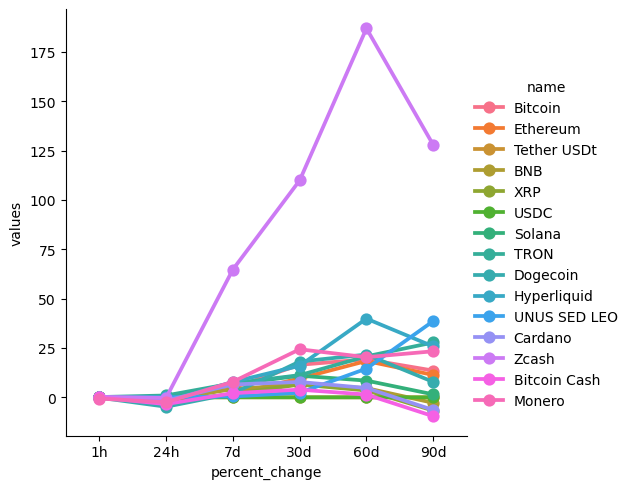

In [39]:
sns.catplot(x='percent_change', y='values', hue='name', data=df7, kind='point')

In [46]:
df10 = df[['name','quote.USD.price','Timestamp']]
df10 = df10.query("name == 'Bitcoin'")
df10

,name,quote.USD.price,Timestamp
0,Bitcoin,79863.33975,NaT
15,Bitcoin,79731.58981,2026-05-07 19:34:06.334422
30,Bitcoin,79788.78202,2026-05-07 19:35:06.551015
45,Bitcoin,79741.11423,2026-05-07 19:36:06.770891
60,Bitcoin,79763.42320,2026-05-07 19:37:07.002630
75,Bitcoin,79763.42320,2026-05-07 19:38:07.210684
90,Bitcoin,80186.26344,2026-05-07 20:26:07.671424
105,Bitcoin,80187.69449,2026-05-07 20:27:07.918451
120,Bitcoin,80187.69449,2026-05-07 20:28:08.148247


<Axes: xlabel='Timestamp', ylabel='quote.USD.price'>

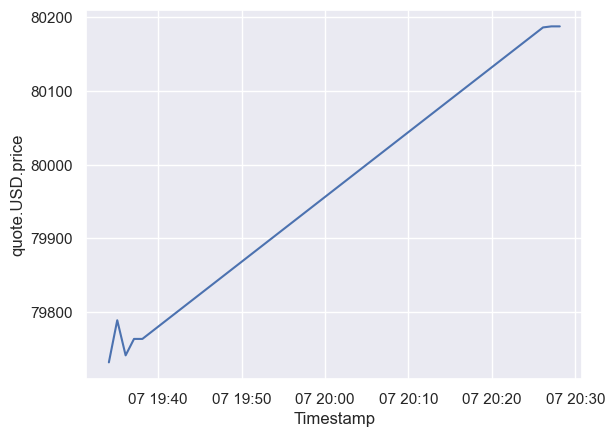

In [47]:
sns.set_theme(style="darkgrid")

sns.lineplot(x='Timestamp', y='quote.USD.price', data = df10)